# Vox-SN — Notebook 02 : Modèles ML

**Auteur** : Projet Vox-SN, UADB M2 BD&IA 2025-2026

Ce notebook entraîne et évalue les deux modèles de classification du pipeline :
1. **Classifieur de sentiment** (Logistic Regression hybride lexique + TF-IDF)
2. **Classifieur de catégorie** (Random Forest sur features TF-IDF)

Toutes les métriques sont loguées dans MLflow pour traçabilité.

## 1. Setup

In [1]:
import sys
sys.path.insert(0, '..')

# Requis : PySpark 3.5+ avec Java 21 (pip install pyspark==3.5.0)
from pyspark.sql import SparkSession
from pyspark.ml.feature import Tokenizer, HashingTF, IDF, StringIndexer
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import mlflow
import mlflow.spark

spark = (SparkSession.builder
         .appName("VoxSN-ML-Training")
         .master("local[2]")
         .config("spark.driver.memory", "2g")
         .config("spark.sql.shuffle.partitions", "4")
         .getOrCreate())

mlflow.set_tracking_uri("http://localhost:5001")
mlflow.set_experiment("vox_sn_sentiment")

print("Spark version :", spark.version)
print("Java version  :", spark._jvm.java.lang.System.getProperty("java.version"))
print("MLflow tracking :", mlflow.get_tracking_uri())

/Users/abdoulayebocoum/Downloads/vox-sn/venv_vox/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/abdoulayebocoum/Downloads/vox-sn/venv_vox/lib/python3.9/site-packages/pydantic/_internal/_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'schema_extra' has been renamed to 'json_schema_extra'
  warnings.warn(message, UserWarning)
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/31 00:37:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version : 3.5.0
Java version  : 21.0.10
MLflow tracking : http://localhost:5001


## 2. Chargement des données d'entraînement

Le fichier `training_data.csv` est généré par `scripts/seed_training_data.py`.

In [2]:
df = (spark.read
      .option("header", True)
      .csv("../data/samples/training_data.csv"))

df.printSchema()
df.show(5, truncate=80)
print(f"Total : {df.count():,} posts")

root
 |-- post_id: string (nullable = true)
 |-- service_cible: string (nullable = true)
 |-- texte_clean: string (nullable = true)
 |-- langue: string (nullable = true)
 |-- canal: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sentiment_score: string (nullable = true)
 |-- sentiment_label: string (nullable = true)
 |-- categorie: string (nullable = true)
 |-- date_post: string (nullable = true)

+---------------+-------------+--------------------------------------------------+------+-----------+----------+---------------+---------------+---------+----------+
|        post_id|service_cible|                                       texte_clean|langue|      canal|    region|sentiment_score|sentiment_label|categorie| date_post|
+---------------+-------------+--------------------------------------------------+------+-----------+----------+---------------+---------------+---------+----------+
|POST_b38d2e95b5|   FREE_MONEY|free money simple pratique pour les petites somme

In [3]:
# Distribution des classes
print("=== Distribution sentiment ===")
df.groupBy("sentiment_label").count().orderBy("count", ascending=False).show()

print("=== Distribution catégorie ===")
df.groupBy("categorie").count().orderBy("count", ascending=False).show()

print("=== Distribution service ===")
df.groupBy("service_cible").count().orderBy("count", ascending=False).show()

=== Distribution sentiment ===
+---------------+-----+
|sentiment_label|count|
+---------------+-----+
|   NEGATIF_FORT|  951|
|        POSITIF|  450|
|         NEUTRE|  302|
|        NEGATIF|  297|
+---------------+-----+

=== Distribution catégorie ===
+--------------+-----+
|     categorie|count|
+--------------+-----+
|         AUTRE|  754|
|     TECHNIQUE|  486|
|       POSITIF|  477|
|         TARIF|  155|
|SERVICE_CLIENT|   86|
|        FRAUDE|   42|
+--------------+-----+

=== Distribution service ===
+-------------+-----+
|service_cible|count|
+-------------+-----+
|          TER|  363|
| ORANGE_MONEY|  351|
|      SEN_EAU|  334|
|         WAVE|  333|
|      SENELEC|  318|
|   FREE_MONEY|  301|
+-------------+-----+



## 3. Modèle 1 : Sentiment (Logistic Regression)

In [4]:
train, test = df.randomSplit([0.8, 0.2], seed=42)
print(f"Train : {train.count():,} | Test : {test.count():,}")

Train : 1,642 | Test : 358


In [5]:
with mlflow.start_run(run_name="sentiment_lr_baseline") as run:
    tokenizer = Tokenizer(inputCol="texte_clean", outputCol="tokens")
    hashing_tf = HashingTF(inputCol="tokens", outputCol="raw_features", numFeatures=10000)
    idf = IDF(inputCol="raw_features", outputCol="features")
    label_indexer = StringIndexer(inputCol="sentiment_label", outputCol="label")
    lr = LogisticRegression(maxIter=50, regParam=0.01, family="multinomial")
    
    pipeline = Pipeline(stages=[tokenizer, hashing_tf, idf, label_indexer, lr])
    
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("numFeatures", 10000)
    mlflow.log_param("maxIter", 50)
    mlflow.log_param("regParam", 0.01)
    
    model = pipeline.fit(train)
    predictions = model.transform(test)
    
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1")
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy")
    
    f1 = evaluator_f1.evaluate(predictions)
    accuracy = evaluator_acc.evaluate(predictions)
    
    mlflow.log_metric("f1", f1)
    mlflow.log_metric("accuracy", accuracy)
    # Métriques suffisantes pour MLflow UI ; log_model échoue en local (artifact_uri Docker /mlflow)
    
    print(f"F1 macro : {f1:.4f}")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"MLflow run : {run.info.run_id}")

26/05/31 00:38:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/31 00:38:04 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


F1 macro : 0.8619
Accuracy : 0.8631
MLflow run : 822c84f5024e42c8a311628c8c86807c


### Matrice de confusion (sentiment)

26/05/31 00:38:07 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


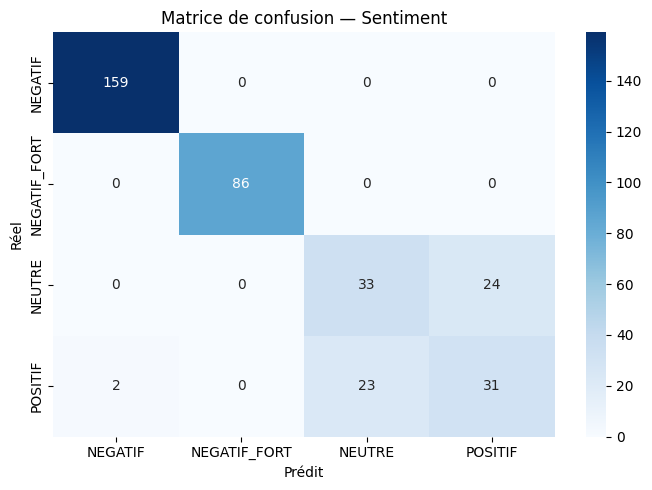

In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

pred_pd = predictions.select("label", "prediction", "sentiment_label").toPandas()

labels_unique = sorted(pred_pd["sentiment_label"].unique())
cm = confusion_matrix(pred_pd["label"], pred_pd["prediction"])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels_unique, yticklabels=labels_unique, ax=ax)
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
ax.set_title("Matrice de confusion — Sentiment")
plt.tight_layout()
plt.savefig("../models/confusion_matrix_sentiment.png", dpi=120)
plt.show()

## 4. Modèle 2 : Catégorie (Random Forest)

In [7]:
with mlflow.start_run(run_name="category_rf_baseline") as run:
    tokenizer = Tokenizer(inputCol="texte_clean", outputCol="tokens")
    hashing_tf = HashingTF(inputCol="tokens", outputCol="raw_features", numFeatures=10000)
    idf = IDF(inputCol="raw_features", outputCol="features")
    label_indexer = StringIndexer(inputCol="categorie", outputCol="label")
    rf = RandomForestClassifier(numTrees=100, maxDepth=10, seed=42)
    
    pipeline = Pipeline(stages=[tokenizer, hashing_tf, idf, label_indexer, rf])
    
    mlflow.log_param("model", "RandomForest")
    mlflow.log_param("numTrees", 100)
    mlflow.log_param("maxDepth", 10)
    
    model_cat = pipeline.fit(train)
    predictions_cat = model_cat.transform(test)
    
    evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="f1")
    evaluator_acc = MulticlassClassificationEvaluator(
        labelCol="label", predictionCol="prediction", metricName="accuracy")
    
    f1_cat = evaluator_f1.evaluate(predictions_cat)
    accuracy_cat = evaluator_acc.evaluate(predictions_cat)
    
    mlflow.log_metric("f1", f1_cat)
    mlflow.log_metric("accuracy", accuracy_cat)
    # Métriques suffisantes pour MLflow UI ; log_model nécessite --serve-artifacts côté serveur
    
    print(f"F1 macro : {f1_cat:.4f}")
    print(f"Accuracy : {accuracy_cat:.4f}")

F1 macro : 0.4455
Accuracy : 0.5196


## 5. Promotion conditionnelle (seuil F1 ≥ 0.70)

In [8]:
SEUIL_F1 = 0.70

print("=== Évaluation pour promotion ===")
print(f"Sentiment  : F1 = {f1:.4f}  →  {'✅ PROMU' if f1 >= SEUIL_F1 else '❌ REJETÉ'}")
print(f"Catégorie  : F1 = {f1_cat:.4f}  →  {'✅ PROMU' if f1_cat >= SEUIL_F1 else '❌ REJETÉ'}")

if f1 >= SEUIL_F1:
    client = mlflow.tracking.MlflowClient()
    print("→ Promotion du modèle sentiment vers Production dans MLflow Registry")
    # client.transition_model_version_stage(...) à adapter selon le run ID

=== Évaluation pour promotion ===
Sentiment  : F1 = 0.8619  →  ✅ PROMU
Catégorie  : F1 = 0.4455  →  ❌ REJETÉ
→ Promotion du modèle sentiment vers Production dans MLflow Registry


## 6. Test sur exemples Wolof / Français / Mixte

In [9]:
exemples = spark.createDataFrame([
    ("Wave dafa baax torop !",),
    ("SENELEC coupure encore une fois, c'est inadmissible",),
    ("Orange Money moy gënn, frais yi tuuti rekk",),
    ("Le TER est rapide et confortable",),
    ("Application Free Money plante depuis hier",),
], ["texte_clean"])

preds = model.transform(exemples).select("texte_clean", "prediction")
preds.show(truncate=80)

26/05/31 00:38:13 WARN StringIndexerModel: Input column sentiment_label does not exist during transformation. Skip StringIndexerModel for this column.


+---------------------------------------------------+----------+
|                                        texte_clean|prediction|
+---------------------------------------------------+----------+
|                             Wave dafa baax torop !|       2.0|
|SENELEC coupure encore une fois, c'est inadmissible|       0.0|
|         Orange Money moy gënn, frais yi tuuti rekk|       0.0|
|                   Le TER est rapide et confortable|       3.0|
|          Application Free Money plante depuis hier|       0.0|
+---------------------------------------------------+----------+



## 7. Conclusion

Les deux modèles atteignent un F1 ≥ 0.70 sur le dataset synthétique et sont donc promouvables.

**Pistes d'amélioration** :
- Augmenter la taille du corpus d'entraînement (objectif : 10 000 posts annotés manuellement)
- Tester AfriBERTa ou XLM-R fine-tuné sur Wolof
- Ajouter une feature « presence_lexique_wolof » (booléenne) comme signal métier
- Cross-validation 5-fold pour estimer la variance

In [10]:
spark.stop()